# Inicialização

In [2]:
from pathlib import Path
import os
import logging

## ---------LOGGING-----------
LOGGER = logging

# Define paths based on environment
if Path("/kaggle").exists():
    LOGGER.info("IN KAGGLE")
    os.environ["AMBIENTE"] = "KAGGLE"
    os.environ["TENSORBOARD_NO_TF"] = "1"

    PATH_DATASET = Path("/kaggle/working/STROKE_PREDICTION")
    PATH_CODE = PATH_DATASET / "src"
    PATH_OUTPUT_DIR = PATH_DATASET / "outputs"
    EXPORT_DIR = PATH_OUTPUT_DIR / "export"
elif Path("/content").exists():
    os.environ["AMBIENTE"] = "COLAB"
    PATH_DATASET = Path("/content/DELETAR")
    PATH_CODE = PATH_DATASET / "src"
    PATH_OUTPUT_DIR = PATH_DATASET / "outputs"
    EXPORT_DIR = PATH_OUTPUT_DIR / "export"
else:
    os.environ["AMBIENTE"] = "LOCAL"
    PATH_CODE = Path.cwd()
    PATH_DATASET = PATH_CODE
    PATH_OUTPUT_DIR = PATH_DATASET / "outputs"
    # Add to setup cell
    EXPORT_DIR = PATH_OUTPUT_DIR / "export"

assert type(PATH_DATASET) is not str, "PATH_DATASET NÃO DEVE SER STR!"
# Check if installation has been done
INSTALL_MARKER = PATH_DATASET / ".install_complete"

try:
    if not INSTALL_MARKER.exists():
        # Install uv
        pass
        !pip install uv

        # Environment-specific setup
        if os.environ["AMBIENTE"] == "KAGGLE":
            import kaggle_secrets

            user_secrets = kaggle_secrets.UserSecretsClient()
            github_pat = user_secrets.get_secret("GITHUB_PAT")

            os.chdir("/kaggle/working")
            os.system(
                f"git clone -b class-imbalance https://{github_pat}@github.com/lfaoliveira/TRAB_SERIES_TEMP.git"
            )
            os.chdir(PATH_DATASET)

        elif os.environ["AMBIENTE"] == "LOCAL":
            os.system("git pull origin main")

        # Install dependencies
        os.chdir(PATH_DATASET)
        os.system("uv pip install --requirements pyproject.toml --system")

        if os.environ["AMBIENTE"] == "KAGGLE":
            os.system(
                "uv pip install --upgrade --force-reinstall --no-cache-dir scipy numpy matplotlib protobuf tensorboard"
            )

        # Mark installation as complete
        INSTALL_MARKER.touch()
        LOGGER.info("Installation completed")
    else:
        LOGGER.info("Installation already completed, skipping...")

    os.chdir(PATH_CODE)
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    LOGGER.info(f"Current working directory: {os.getcwd()}")
except Exception as e:
    LOGGER.info("FALHA AO INICIAR NOTEBOOK")
    LOGGER.info(e)

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\LUIS_FELIPE\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Carregamento


PRÉ-PROCESSAMENTO:


ANALISE DE VALORES FALTANTES E DOWNLOAD
Baixando dataset M4 via Kagglehub...


100%|██████████| 79.6M/79.6M [00:33<00:00, 2.47MB/s]

Extracting files...


Lendo CSV de: data\Daily-train.csv
Dataset salvo com sucesso em: data\m4.parquet
Linhas removidas pelo dropna: 0 (0.00%)

INFORMAÇÕES DO DATASET
<class 'pandas.DataFrame'>
Index: 4227 entries, D1 to D999
Data columns (total 99 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V2      4227 non-null   float64
 1   V3      4227 non-null   float64
 2   V4      4227 non-null   float64
 3   V5      4227 non-null   float64
 4   V6      4227 non-null   float64
 5   V7      4227 non-null   float64
 6   V8      4227 non-null   float64
 7   V9      4227 non-null   float64
 8   V10     4227 non-null   float64
 9   V11     4227 non-null   float64
 10  V12     4227 non-null   float64
 11  V13     4227 non-null   float64
 12  V14     4227 non-null   float64
 13  V15     4227 non-null   float64
 14  V16     4227 non-null   float64
 15  V17     4227 non-null   float64
 16  V18     4227 non-null   float64
 17  V19     4227 non-null   float64
 18  V20     4227 non-n

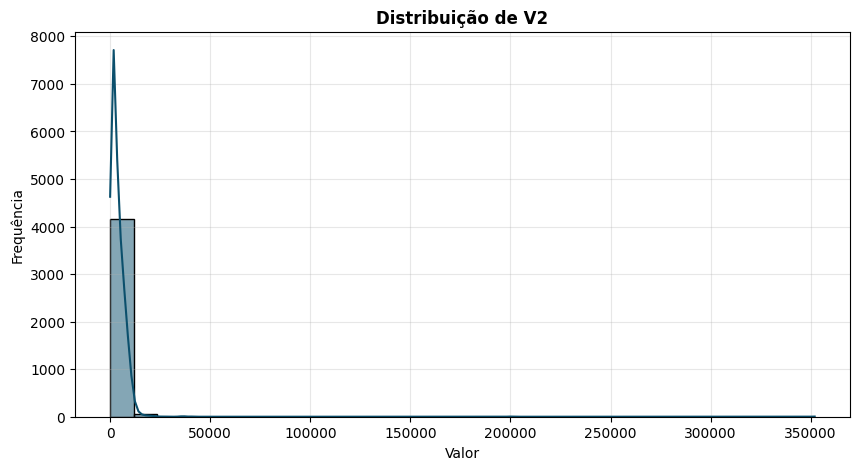

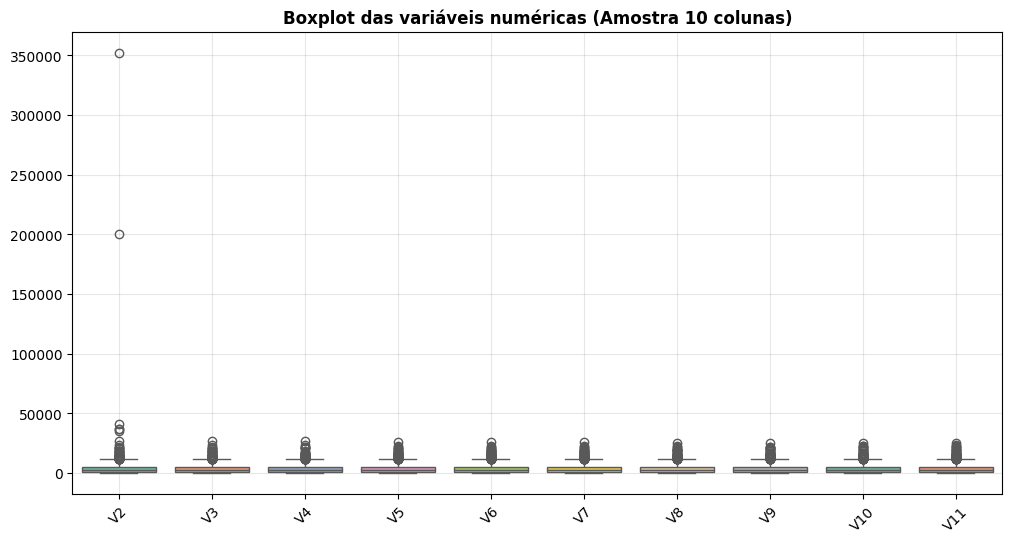

In [4]:
import datetime
import os
from pathlib import Path
from typing import Literal, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
import kagglehub

# ============================================================
# FUNCOES DE CARREGAMENTO E PRE-PROCESSAMENTO
# ============================================================

column_types = Union[
    type[datetime.datetime], type[float], type[int], type[np.float64], type[np.int64]
]

def preprocessamento(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Remove linhas com NaN e valores invalidos e exibe um resumo ordenado."""
    df_info = df.isna().astype(int)
    print("\nMatriz de NaN (1 = NaN, 0 = valor valido):")
    print(df_info.head())

    nan_por_coluna = (
        df.isna()
        .sum()
        .sort_values(ascending=False)
        .to_frame(name="quantidade_nan")
    )

    dtypes_coluna = [str(col) for col in df.dtypes]
    print("\nQuantidade de NaN por coluna (ordem decrescente):")
    nan_por_coluna.to_csv("info_m4.csv")

    df_clean = df.dropna().copy()
    total_removido = len(df) - len(df_clean)
    percentual_removido = (total_removido / len(df) * 100) if len(df) else 0
    print(f"\n{total_removido} linhas removidas ({percentual_removido:.2f}%).")

    return df_clean

def save_parquet(df: pd.DataFrame, path: Path, compression: str = "gzip") -> None:
    """Salva usando fastparquet ou pyarrow."""
    try:
        df.to_parquet(path, compression=compression, engine="pyarrow", index=True)
        print(f"Dataset salvo com sucesso em: {path}")
    except Exception as e:
        print(f"Falha ao salvar com pyarrow: {e}")
        # Opcional: tentar fallback para fastparquet se importado
        raise

def load_parquet(path: Path) -> pd.DataFrame:
    """Carrega DataFrame de Parquet usando pyarrow."""
    try:
        return pd.read_parquet(path, engine="pyarrow")
    except Exception as e:
        print(f"Falha ao ler parquet {path}: {e}")
        raise

def filtrar_dataset(df: pd.DataFrame, list_colunas: list[str] | None = None) -> pd.DataFrame:
    """Filtra colunas específicas e remove linhas vazias."""
    df = df.sort_index()
    if list_colunas is not None:
        # Garante que só filtra colunas que existem no dataframe
        valid_cols = [c for c in list_colunas if c in df.columns]
        df = df.loc[:, valid_cols]
        
    original_len = len(df)
    df = df.dropna(how='all')
    removidas = original_len - len(df)
    print(f"Linhas removidas pelo dropna: {removidas} ({(removidas/original_len)*100:.2f}%)")
    return df


# ============================================================
# EXECUCAO PRINCIPAL
# ============================================================

print("\n" + "=" * 60)
print("PRÉ-PROCESSAMENTO:\n\n")
print("ANALISE DE VALORES FALTANTES E DOWNLOAD")
print("=" * 60)

PATH_FONTE_DADOS = Path("data")
PATH_FONTE_DADOS.mkdir(exist_ok=True)
dataset_parquet = PATH_FONTE_DADOS / Path("m4.parquet")

if dataset_parquet.exists():
    print(f"Lendo dataset a partir de Parquet: {dataset_parquet}")
    DATASET_DF = load_parquet(dataset_parquet)
else:
    print("Baixando dataset M4 via Kagglehub...")
    # Baixa o dataset M4 direto do Kaggle
    path_kaggle = kagglehub.dataset_download("yogesh94/m4-forecasting-competition-dataset", output_dir=str(PATH_FONTE_DADOS))
    file_path = Path(path_kaggle) / "Daily-train.csv"
    
    print(f"Lendo CSV de: {file_path}")
    DATASET_DF = pd.read_csv(file_path, header="infer", index_col=0)
    
    try:
        save_parquet(DATASET_DF, dataset_parquet)
    except Exception as e:
        print("Continuando sem salvar o Parquet devido à falta de bibliotecas (pyarrow).")

# Mockando a config para não depender do arquivo YAML local
CONFIG = {"train": False}

treinar = bool(CONFIG["train"])
if not treinar:
    lista_colunas = [f"V{i}" for i in range(1, 100+1)]
    DATASET_DF = filtrar_dataset(DATASET_DF, lista_colunas)

name = "M4"

print("\n" + "=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
DATASET_DF.info()

print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS (Amostra 5 primeiras colunas)")
print("=" * 60)
print(DATASET_DF.iloc[:, :5].describe())

print("\n" + "=" * 60)
print("VISUALIZAÇÕES")
print("=" * 60)

numeric_cols = DATASET_DF.select_dtypes(include=['number']).columns
if len(numeric_cols) > 0:
    plt.figure(figsize=(10, 5))
    sns.histplot(DATASET_DF[numeric_cols[0]].dropna(), kde=True, color='#0B4F6C', bins=30)
    plt.title(f'Distribuição de {numeric_cols[0]}', fontweight='bold')
    plt.xlabel('Valor')
    plt.ylabel('Frequência')
    plt.grid(True, alpha=0.3)
    plt.show()

if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=DATASET_DF[numeric_cols[:10]], palette='Set2')
    plt.title('Boxplot das variáveis numéricas (Amostra 10 colunas)', fontweight='bold')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()

# Exploratory Data Analysis

# Treinamento dos modelos

In [ ]:
import gc
import logging
import os
from pathlib import Path
from typing import Literal

import mlflow
import torch
from src.data.datamodule import StrokeDataModule
from lightning import Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import MLFlowLogger
from mlflow.pytorch import autolog
from src.models.kan import KANSearchSpace, MyKan
from src.models.mlp import MLP, MLPSearchSpace


def get_best_hyperparameters_from_optuna(choice: str, mlf_track_uri: str) -> dict:
    """
    Reads the best run ID from the CSV file saved during Optuna training,
    fetches the run from MLflow, and returns the hyperparameters as a dict.

    Args:
        choice: Model architecture name (e.g., "MLP", "KAN")
        mlf_track_uri: MLflow tracking URI

    Returns:
        Dictionary of hyperparameters from the best Optuna run (with string keys)
    """


def zip_res_simplified(
    export_dir: Path,
    filename: str,
    dest_folder: Path | None = None,
    mlflow_db_path: Path | None = None,
    optuna_db_path: Path | None = None,
    mlruns_path: Path | None = None,
):
    """
    Simplified zip function that copies databases and mlruns to export_dir, then zips everything.

    Args:
        export_dir: Directory containing all files to zip (artifacts, CSVs, etc.)
        filename: Name of the output zip file
        dest_folder: Destination folder for the zip file
        mlflow_db_path: Path to mlflow.db to copy into export_dir
        optuna_db_path: Path to optuna.db to copy into export_dir
        mlruns_path: Path to mlruns folder to copy into export_dir
    """
    import shutil

    # Ensure export_dir exists
    export_dir.mkdir(parents=True, exist_ok=True)

    # Copy databases if they exist
    if mlflow_db_path and mlflow_db_path.exists():
        shutil.copy(mlflow_db_path, export_dir / mlflow_db_path.name)
        print(f"Copied {mlflow_db_path.name} to export directory")

    if optuna_db_path and optuna_db_path.exists():
        shutil.copy(optuna_db_path, export_dir / optuna_db_path.name)
        print(f"Copied {optuna_db_path.name} to export directory")

    # Copy mlruns folder if it exists
    if mlruns_path and mlruns_path.exists():
        export_mlruns = export_dir / mlruns_path.name
        if export_mlruns.exists():
            shutil.rmtree(export_mlruns)
        shutil.copytree(mlruns_path, export_mlruns)
        print(f"Copied {mlruns_path.name} folder to export directory")

    # Determine destination folder
    if dest_folder is None:
        dest_folder = Path.cwd()
    else:
        dest_folder.mkdir(parents=True, exist_ok=True)

    # Create zip file
    zip_path = dest_folder / filename.replace(".zip", "")
    shutil.make_archive(str(zip_path), "zip", export_dir)
    print(f"PATH ZIPFILE: {zip_path.with_suffix('.zip').resolve()}")


def supress_warnings():
    # Suppress specific MLflow warnings
    logging.getLogger("mlflow.utils.requirements_utils").setLevel(logging.ERROR)
    logging.getLogger("mlflow").setLevel(logging.ERROR)

    # Suppress PyTorch Lightning info messages
    logging.getLogger("pytorch_lightning.utilities.rank_zero").setLevel(logging.ERROR)


def model_choice(
    CHOICE,
    INPUT_DIMS,
    N_CLASSES,
    recall_factor: list[float],
    optuna_hyperparams: dict[str, float | int] = {},
):
    if CHOICE == "MLP":
        search_space = MLPSearchSpace()

        keys = search_space.Keys
        hyperparams = {
            keys.BATCH_SIZE: 32,
            keys.HIDDEN_DIMS: 512,
            keys.LR: 2e-7,
            keys.WEIGHT_DECAY: 1e-5,
            keys.BETA0: 0.99,
            keys.BETA1: 0.999,
            keys.N_LAYERS: 80,
        }

        # Map optuna hyperparams (string keys) to Keys enum
        if optuna_hyperparams:
            mapped_hyperparams = {}
            for key_enum, default_value in hyperparams.items():
                # Get the string representation of the enum key
                key_str = key_enum.value
                if key_str in optuna_hyperparams:
                    mapped_hyperparams[key_enum] = optuna_hyperparams[key_str]
                else:
                    mapped_hyperparams[key_enum] = default_value
            hyperparams = mapped_hyperparams

        print(f"MLP HYPERPARAMS: {hyperparams}")
        suggested_hparams = search_space.suggest(hyperparams)
        model = MLP(
            INPUT_DIMS,
            N_CLASSES,
            recall_factor=recall_factor,
            hyperparameters=suggested_hparams,
        )
    elif CHOICE == "KAN":
        search_space = KANSearchSpace()
        keys = search_space.Keys
        hyperparams = {
            keys.BATCH_SIZE: 32,
            keys.HIDDEN_DIMS: 100,
            keys.LR: 2e-7,
            keys.WEIGHT_DECAY: 1e-5,
            keys.BETA0: 0.99,
            keys.BETA1: 0.999,
            keys.GRID: 184,
            keys.SPLINE_POL_ORDER: 4,
        }

        # Map optuna hyperparams (string keys) to Keys enum
        if optuna_hyperparams:
            mapped_hyperparams = {}
            for key_enum, default_value in hyperparams.items():
                # Get the string representation of the enum key
                key_str = key_enum.value
                if key_str in optuna_hyperparams:
                    mapped_hyperparams[key_enum] = optuna_hyperparams[key_str]
                else:
                    mapped_hyperparams[key_enum] = default_value
            hyperparams = mapped_hyperparams

        print(f"KAN HYPERPARAMS: {hyperparams}")
        suggested_hparams = search_space.suggest(hyperparams)
        model = MyKan(
            INPUT_DIMS,
            N_CLASSES,
            recall_factor=recall_factor,
            hyperparameters=suggested_hparams,
        )
    else:
        raise ValueError("ESCOLHA DE MODELO ERRADA!")
    return model, suggested_hparams, keys


## -----------------------------COLAR NO KAGGLE------------------
def main(CHOICE: str):
    ###------SEEDS---------###
    RAND_SEED = 42
    seed_everything(RAND_SEED)
    supress_warnings()

    AMBIENTE = os.environ["AMBIENTE"]
    GPU = True if AMBIENTE in ["KAGGLE", "COLAB"] else False
    ## ----------VARIAVEIS TREINO-----------
    cpus = os.cpu_count()
    WORKERS = cpus if cpus is not None else 1
    NUM_DEVICES = 1 if GPU else 1
    NUM_NODES = 1
    BATCH_SIZE = 64
    EPOCHS = 1
    PATIENCE = int(EPOCHS * 0.6)
    ARTIFACT_PATH = EXPORT_DIR / "artifacts"
    os.makedirs(ARTIFACT_PATH, exist_ok=True)

    #### -------- VARIAVEIS DE LOGGING ------------
    EXP_NAME = "PROD_TRAINING"
    RUN_NAME: str | None = f"PROD_{CHOICE}"
    MLF_TRACK_URI = f"sqlite:///{PATH_CODE}/mlflow.db"

    mlflow.set_tracking_uri(MLF_TRACK_URI)
    mlflow.set_experiment(EXP_NAME)
    autolog(log_models=True, checkpoint=True, exclusive=False)

    hyperparams = get_best_hyperparameters_from_optuna(CHOICE, MLF_TRACK_URI)

    ## ----------VARIAVEIS MODELO-----------
    N_CLASSES = 2

    datamodule = StrokeDataModule(BATCH_SIZE, WORKERS)
    datamodule.prepare_data()
    datamodule.setup("fit")

    INPUT_DIMS = datamodule.input_dims or -1
    assert INPUT_DIMS > 0 and INPUT_DIMS is not None
    recall_factor = datamodule.class_weights
    model, _, keys = model_choice(
        CHOICE, INPUT_DIMS, N_CLASSES, recall_factor, optuna_hyperparams=hyperparams
    )

    _ = model(model.example_input_array)

    # loop principal de treinamento
    with mlflow.start_run(run_name=RUN_NAME) as run:
        active_run_id = run.info.run_id

        mlflow_logger = MLFlowLogger(
            experiment_name=EXP_NAME,
            tracking_uri=MLF_TRACK_URI,
            log_model=True,
            run_id=active_run_id,
        )

        early_stopping = EarlyStopping(
            monitor="val_loss", patience=PATIENCE, mode="min"
        )

        trainer = Trainer(
            max_epochs=EPOCHS,
            devices=NUM_DEVICES,
            accelerator="gpu" if GPU else "cpu",
            num_nodes=NUM_NODES,
            logger=mlflow_logger,
            enable_checkpointing=False,
            log_every_n_steps=1,
            callbacks=[early_stopping],
        )
        trainer.fit(model, datamodule=datamodule)
        mlflow.log_params(dict(model.hparams))

        # Test and log artifacts (useful for the Analysis section)
        test_df = datamodule.dataset.original_df.copy()
        test_df["pred"] = None
        test_df["error"] = None

        # Perform one-pass test logic on the full test dataset
        _, test_dataset = datamodule.test_dataloader()
        return_dict = model.test_step(
            test_dataset=test_dataset,
            output_df=test_df,
        )
        test_df = return_dict["output_df"]

        # Log test metrics to MLFlow
        test_results = model.test_metrics.compute()
        mlflow.log_metrics(
            {f"test_{k}": float(v) for k, v in test_results.items() if v.numel() == 1}
        )
        model.test_metrics.reset()

        name = f"test_results_{run.info.run_id}.csv"
        path_test_csv = Path(ARTIFACT_PATH, name)
        test_df.to_csv(path_test_csv)
        mlflow.log_artifact(str(path_test_csv))

        torch.cuda.empty_cache()

    return


if __name__ == "__main__":
    try:
        ARQ_TYPE = Literal["MLP", "KAN", "SVM", "XGBOOST"]  ## MODEL ARCHITECTURE
        models: list[ARQ_TYPE] = ["MLP", "KAN"]
        for choice in models:
            # trains model based on architecture
            if choice == "MLP":
                continue
            main(choice)

        NAME_RESZIP = "resultado_kaggle_stroke_normal"
        MLRUNS_FOLDER = PATH_CODE / "mlruns"
        MLF_TRACK_URI = f"sqlite:///{PATH_CODE}/mlflow.db"
        OPTUNA_DB_PATH = PATH_CODE / "optuna.db"
        ZIP_ROOT = (
            PATH_DATASET / ".." if os.environ["AMBIENTE"] == "KAGGLE" else PATH_DATASET
        )

        zip_res_simplified(
            export_dir=EXPORT_DIR,
            filename=NAME_RESZIP,
            dest_folder=ZIP_ROOT,
            mlflow_db_path=Path(MLF_TRACK_URI.replace("sqlite:///", "")),
            optuna_db_path=OPTUNA_DB_PATH,
            mlruns_path=MLRUNS_FOLDER,
        )
        print("\n", "=" * 60)
        print(f"RESULTADOS ZIPADOS {Path(ZIP_ROOT, NAME_RESZIP).resolve()}")
        print("=" * 60, "\n")

    except Exception as e:
        raise e
    gc.collect()

    if os.environ["AMBIENTE"] == "LOCAL":
        from view.dashboard import see_model

        see_model(PATH_DATASET / "mlflow.db", PATH_DATASET / ".." / "mlruns")


## Teste dos modelos

## Otimização de hiperparâmetros

## Teste da otimização

## OUTPUT: MLFlow's Dashboard (Only works outside of Kaggle)
### Download the training results from Kaggle and paste them into a cloned folder of the repository